# **EuroSAT V2 Pipeline: Exploratory Data Analysis (EDA)**

#### **Objective**
Before initializing any deep learning or quantum models, we must verify the integrity of our data pipeline.

This notebook downloads the EuroSAT RGB dataset, validates the PyTorch tensor shapes and visually renders a sample from all 10 land cover classes to ensure our normalization and data-loading logic is functioning perfectly.

#### **Clone git repo, setup environment and install requirements**

In [1]:
import os
import sys

# Clone repo or pull latest changes
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes..")
    os.chdir('/content/QML4EO-reproduction')
    !git pull
else:
    print("Cloning repo for the first time..")
    os.chdir('/content')
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    os.chdir('/content/QML4EO-reproduction')

if '/content/QML4EO-reproduction' not in sys.path:
    sys.path.append('/content/QML4EO-reproduction')

!pip install -r requirements.txt -q

Cloning repo for the first time..
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 126 (delta 49), reused 102 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 13.52 MiB | 39.78 MiB/s, done.
Resolving deltas: 100% (49/49), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 7

#### **Exploratory Data Analysis: Test data loader and verify all 10 land cover classes**

In [2]:
import cv2
import numpy as np
import torch
from google.colab.patches import cv2_imshow
# Import your custom data loader from the src/utils folder
from src.utils.data_loader import get_eurosat_dataloaders

# Load Data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=64,
    img_size=64
)

print(f"\nDiscovered Classes: {classes}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 193MB/s]


Dataset loaded successfully! Total: 27000 | Train: 21600 | Val: 5400

Discovered Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [3]:
# Tensor Shape Sanity Check
images, labels = next(iter(train_loader))
print(f"Batch Image Tensor Shape: {images.shape} -> (Batch, Channels, Height, Width)")
print(f"Batch Label Tensor Shape: {labels.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Image Tensor Shape: torch.Size([64, 3, 64, 64]) -> (Batch, Channels, Height, Width)
Batch Label Tensor Shape: torch.Size([64])


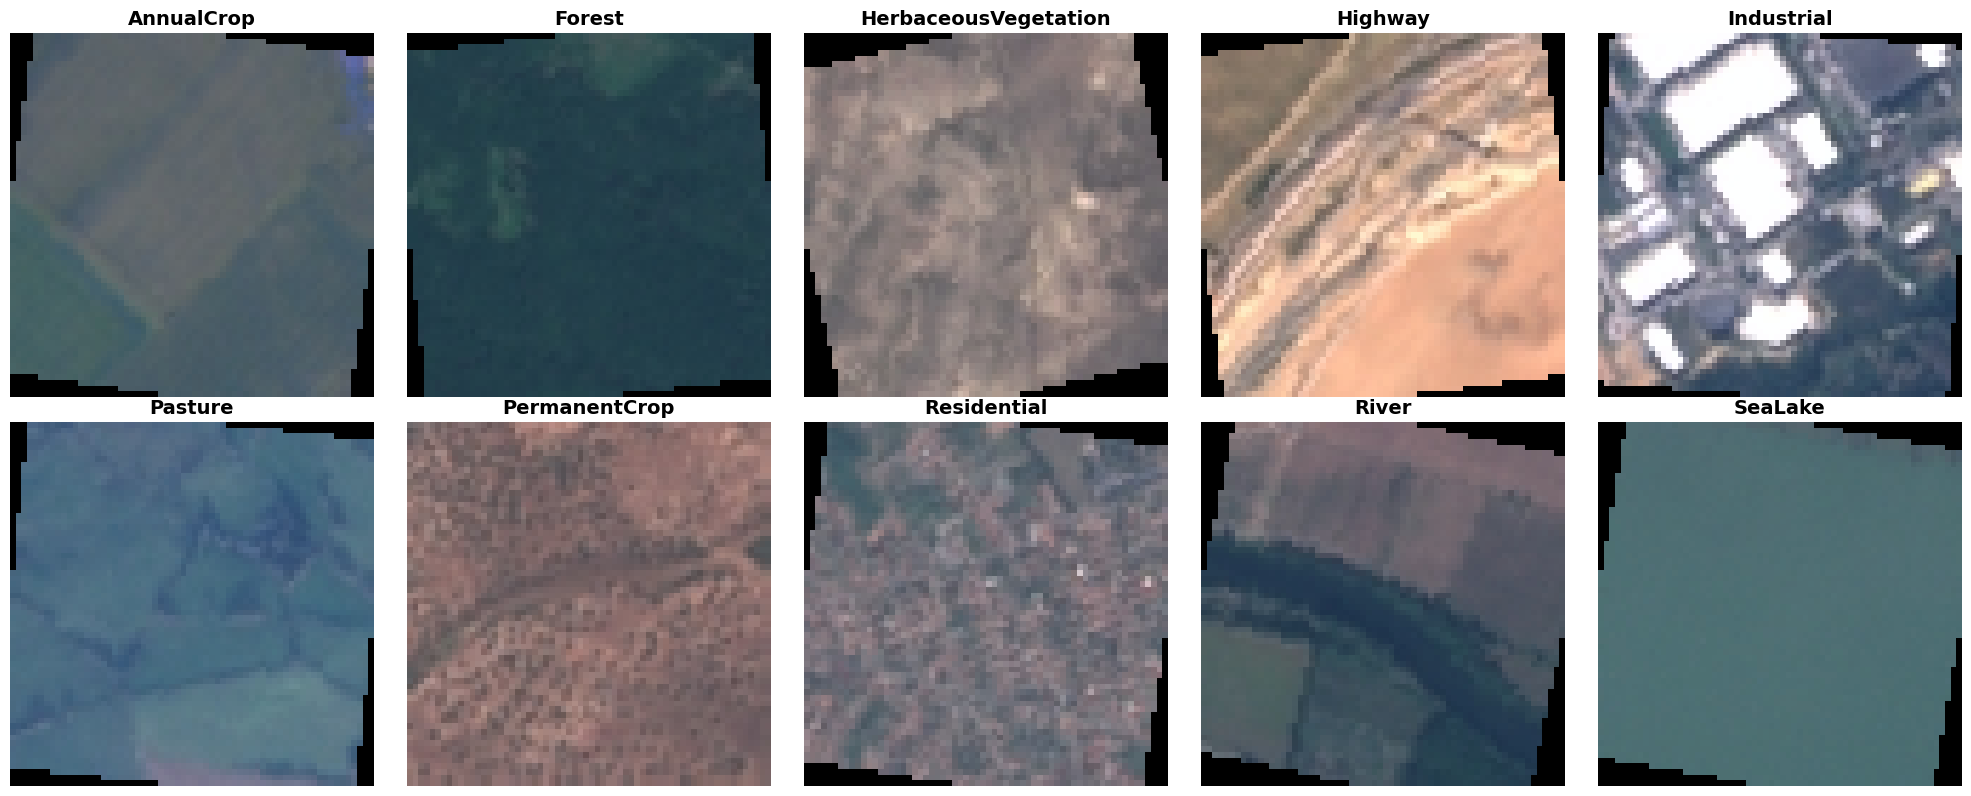

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Scan the dataloader to collect exactly one image from each of the 10 classes
class_images = {}
for batch_images, batch_labels in train_loader:
    for i in range(len(batch_labels)):
        lbl = batch_labels[i].item()
        if lbl not in class_images:
            class_images[lbl] = batch_images[i]
        # Stop searching once we have all 10 classes
        if len(class_images) == len(classes):
            break
    if len(class_images) == len(classes):
        break

# Create a large 2x5 grid for high visibility
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten() # Flatten the 2D grid into a 1D list for easy looping

# ImageNet normalization constants used in data_loader.py
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Plot each class
for class_idx in range(len(classes)):
    # PyTorch uses (C, H, W) but Matplotlib needs (H, W, C)
    img = class_images[class_idx].numpy().transpose((1, 2, 0))
    img = std * img + mean # un-normalize
    img = np.clip(img, 0, 1) # lock pixel values between 0 and 1

    axes[class_idx].imshow(img)
    # Set a large font size for the class titles
    axes[class_idx].set_title(classes[class_idx], fontsize=14, fontweight='bold')
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

*Note: Images are rotated because of our data augmentation pipeline*